# Introduction to the Digital Earth Africa Water Quality Monitoring Service (WQMS)

* **Products used:** 
[wq_annual](https://explorer.dev.digitalearth.africa/products/wq_annual)

## Background
The Water Quality Monitoring Service (WQMS) delivers water quality information for surface water bodies across across the African continent. Earth Observation (EO) data provides continuous spatial coverage and change monitoring at a fraction of the cost and logistical complexity of in-situ monitoring. As national governments across Africa work to address Sub-indicator 2 of [Sustainable Development Goal (SDG) 6.6.1](https://www.unwater.org/our-work/sdg-6-integrated-monitoring-initiative/indicator-661-change-extent-water-related) — Water Quality of Lakes and Artificial Water Bodies — the Water Quality Monitoring System (WQMS) will provide timely, decision-relevant information to support the management and sustainable use of surface water resources. This includes indicators such as the overall water turbidity, and the Trophic State Index, which serves as a proxy for the biological health of a water body.

## Description
This notebook demonstrates how to load the annual DE Africa Water Quality data using the [Open Data Cube](https://opendatacube.readthedocs.io/en/latest/about-core-concepts/index.html) software. Topics covered include:

1. [Load and inspect annual water quality data](#Load-and-inspect-annual-water-quality-data)
2. [Yearly change monitoring](#Yearly-change-monitoring)
3. [Animation over time](#Animation-over-time)

<div class="alert alert-info">
    
**Note:** Visit the [DE Africa Water Quality product documentation](https://knowledge.dea.ga.gov.au/data/category/dea-surface-reflectance/) for detailed technical information including methods, quality, and data access.

</div>

## Getting started

To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell. 

### Load packages
Import Python packages that are used for the analysis.

In [1]:
%matplotlib inline

import datacube
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from deafrica_tools.plotting import display_map, xr_animation

### Connect to the datacube

Connect to the datacube so we can access DE Africa data.
The `app` parameter is a unique name for the analysis which is based on the notebook file name.

In [2]:
dc = datacube.Datacube(app='DE_Africa_Water_Quality_Monitoring_Service')

## Load and inspect annual water quality data

In [3]:
query = {
    "product": "wq_annual",
    "x": (9.56, 9.77),
    "y": (37.11, 37.21),
    "crs": "EPSG:4326",
    "time": ("2000-01-01", "2025-12-31"),
    "output_crs": "EPSG:6933",
    "resolution": (-10, 10),
    "measurements": [
        "tsm",           # Turbidity
        "chla",          # Chlorophyll-A
        "tsi",           # Trophic State Index
        "agm_ndvi",      # NDVI
        "agm_hue",       # Water Hue
        "agm_owt",       # Optical Water Type
        "agm_fai",       # Floating Algal Index
        "clear_water",   # Clear water mask
        "water_mask",    # Water presence mask
        "tirs_st_ann_max", # Max water surface temperature
        "tirs_st_ann_med", # Median water surface temperature
        "tirs_st_ann_min"  # Min water surface temperature
    ]
}

In [4]:
display_map(x=query["x"], y=query["y"])

In [5]:
ds = dc.load(**query)

In [6]:
ds

<xarray.Dataset> Size: 3GB
Dimensions:          (time: 26, y: 1022, x: 2028)
Coordinates:
  * time             (time) datetime64[ns] 208B 2000-07-01T23:59:59.999999 .....
  * y                (y) float64 8kB 4.428e+06 4.427e+06 ... 4.417e+06 4.417e+06
  * x                (x) float64 16kB 9.224e+05 9.224e+05 ... 9.427e+05
    spatial_ref      int32 4B 6933
Data variables:
    tsm              (time, y, x) float32 216MB nan nan nan nan ... nan nan nan
    chla             (time, y, x) float32 216MB nan nan nan nan ... nan nan nan
    tsi              (time, y, x) float32 216MB nan nan nan nan ... nan nan nan
    agm_ndvi         (time, y, x) float32 216MB nan nan nan nan ... nan nan nan
    agm_hue          (time, y, x) float32 216MB nan nan nan nan ... nan nan nan
    agm_owt          (time, y, x) float32 216MB nan nan nan nan ... nan nan nan
    agm_fai          (time, y, x) float32 216MB nan nan nan nan ... nan nan nan
    clear_water      (time, y, x) float32 216MB nan nan nan nan ... nan nan nan
    water_mask       (time, y, x) float32 216MB nan nan nan nan ... nan nan nan
    tirs_st_ann_max  (time, y, x) float32 216MB nan nan nan nan ... nan nan nan
    tirs_st_ann_med  (time, y, x) float32 216MB nan nan nan nan ... nan nan nan
    tirs_st_ann_min  (time, y, x) float32 216MB nan nan nan nan ... nan nan nan
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

### Water Masks
A water presence mask, generated from the WOfS product over a rolling 5-year period (since floating vegetation can dominate the water surface for long periods of time) is provided.

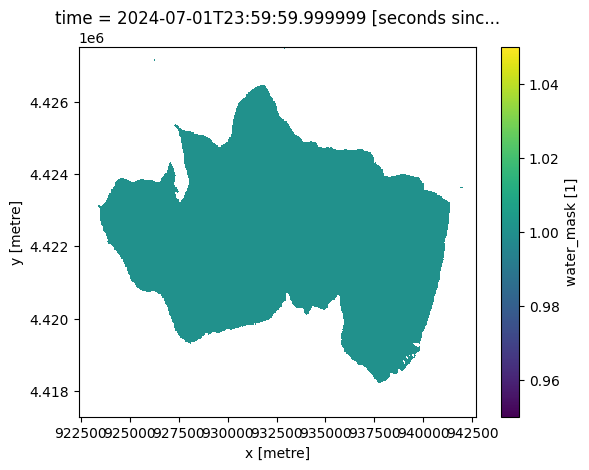

In [7]:
ds.sel(time="2024").water_mask.plot()
plt.show()

### Floating Algae Index (FAI)
The Floating Algae Index is used to detect and monitor floating vegetation and algal blooms, which are often problematic or hazardous. 
FAI supports early warning and risk management. 
Areas of algae and surface vegetation must also be mapped before applying algorithms for Chlorophyll-A or turbidity. 
The FAI is only provided when it is above a threshold of 0.05, i.e., when there's a likely presence of floating algae.

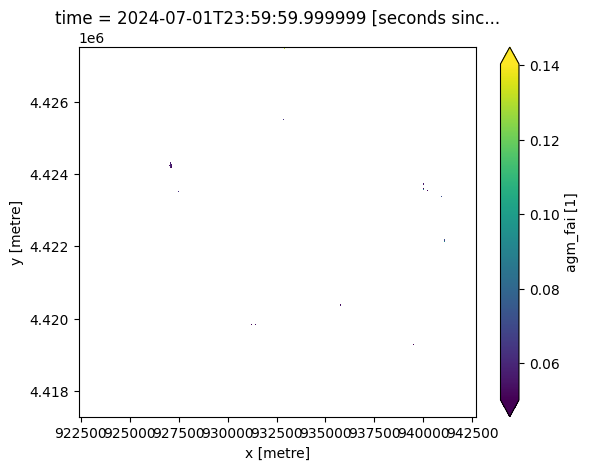

In [8]:
ds.agm_fai.sel(time="2024").plot(robust=True)
plt.show()

### Clear Water Mask
The clear water mask is defined as areas where water is detected and the FAI is below the 0.05 threshold. Subsequent layers—including optical water type, hue, total suspended matter, chlorophyll‑a, and the trophic state index—contain values only within the `clear_water` mask.

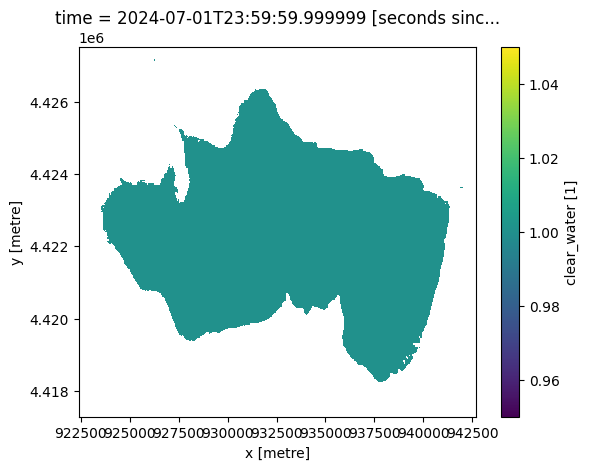

In [9]:
ds.clear_water.sel(time="2024").plot()
plt.show()

### Total Suspended Matter (TSM)
As can be seen above, there are several variables available. 
Below, we plot for each pixel the annual Total Suspended Matter (TSM), which is provided as an indicator on a *relative* scale, with values designed to correspond to $\mathrm{mg}/\mathrm{m^3}$ of suspended particles. 
TSM values are related to the turbidity or the cloudiness of water. Higher TSM values can clog water habitats and reduce ecosystem productivity and oxygen generation.

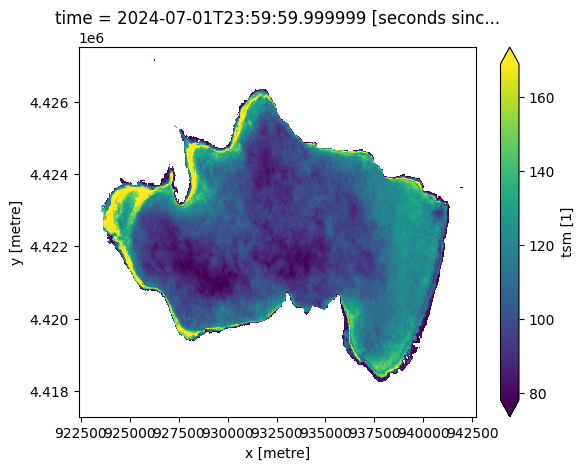

In [10]:
ds.tsm.sel(time="2024").plot(robust=True)
plt.show()

### Chlorophyll-A (ChlA)
Chlorophyll-A is an indicator of algal content, used to identify conditions conducive to algal blooms and assess biological productivity. ChlA is provided as an indicator on a *relative* scale, with values designed to correspond to $\mathrm{mg}/\mathrm{m^3}$. ChlA is readily transformed to the Trophic State Index used in SDG reporting, as is done in the next cell.

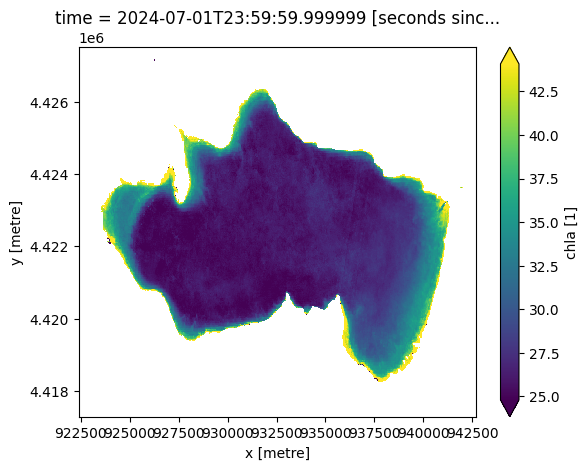

In [11]:
ds.chla.sel(time="2024").plot(robust=True)
plt.show()

### Trophic State Index (TSI)

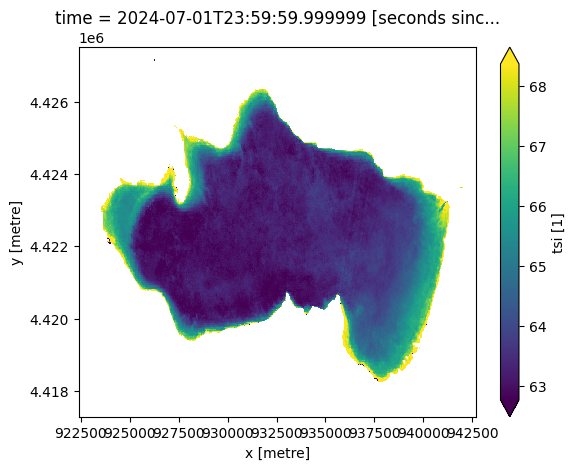

In [12]:
ds.tsi.sel(time="2024").plot(robust=True)
plt.show()

### Hue
The water colour, also known as the hue of the water, derived from the spectral reflectances measured by the EO instruments. Hue is expressed as an angle from 0-360. The hue of the waterbody is an objective way to determine changes in water colour.

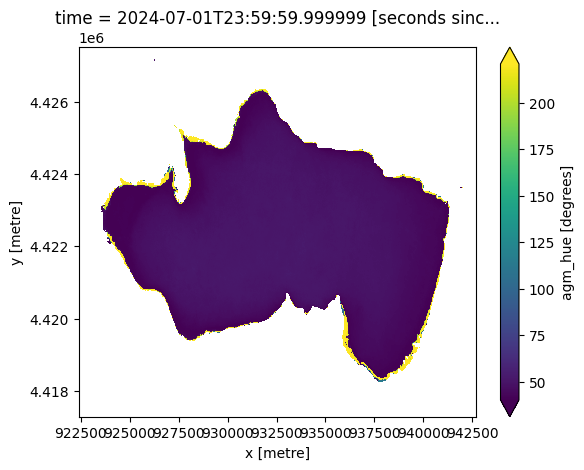

In [13]:
ds.agm_hue.sel(time="2024").plot(robust=True)
plt.show()

### Optical Water Type (OWT)
OWT [(Spyrakos et al., 2018)](https://doi.org/10.1002/lno.10674) is a classification of water types used to support EO based monitoring of water quality. For inland waters 13 OWTs are identified based on their spectral characteristics. These can then be characterised as oligotrophic, eutrophic, or hypereutrophic water types. The OWT of a waterbody may change seasonally or over the longer term.
| OWT   | Class                          | Dominant Characteristics                                                                 |
|-------|--------------------------------|-----------------------------------------------------------------------------------------|
| OWT1  | eutrophic_and_blue_green        | Hypereutrophic waters with scum of cyanobacterial bloom and vegetation-like Rrs         |
| OWT2  | eutrophic_and_blue_green        | Common case waters with diverse reflectance shape and marginal dominance of pigments and CDOM over inorganic suspended particles |
| OWT3  | oligotrophic_clear              | Clear waters                                                                            |
| OWT4  | eutrophic_and_blue_green        | Turbid waters with high organic content                                                 |
| OWT5  | eutrophic_and_blue_green        | Sediment-laden waters                                                                   |
| OWT6  | hyper_eutrophic_green_brown     | Balanced effects of optically active constituents at shorter wavelengths               |
| OWT7  | hyper_eutrophic_green_brown     | Highly productive waters with high cyanobacteria abundance and elevated reflectance at red/near-infrared spectral region |
| OWT8  | hyper_eutrophic_green_brown     | Productive waters with cyanobacteria presence and with Rrs peak close to 700 nm        |
| OWT9  | oligotrophic_clear              | Optically neighboring to OWT2 waters but with higher Rrs at shorter wavelengths        |
| OWT10 | hyper_eutrophic_green_brown     | CDOM-rich waters                                                                         |
| OWT11 | eutrophic_and_blue_green        | Waters high in CDOM with cyanobacteria presence and high absorption efficiency by NAP  |
| OWT12 | eutrophic_and_blue_green        | Turbid, moderately productive waters with cyanobacteria presence                        |
| OWT13 | oligotrophic_clear              | Very clear blue waters                                                                  |

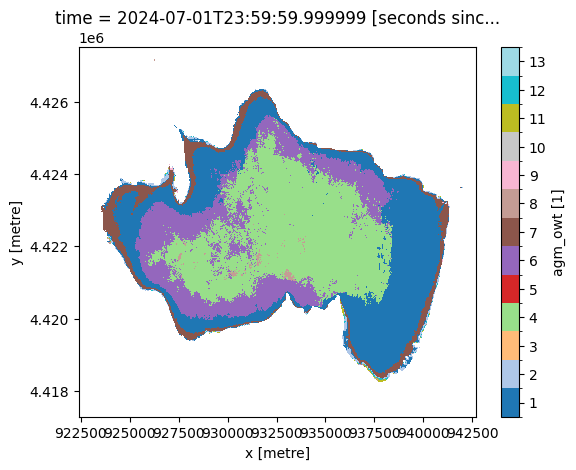

In [14]:
# 13 classes
colors = plt.cm.tab20(np.linspace(0, 1, 13))
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(0.5, 14.5, 1), cmap.N)

# Plot
im = ds.agm_owt.sel(time="2024").plot(cmap=cmap, norm=norm)

# Fix colorbar ticks to show integer class labels
cbar = im.colorbar
cbar.set_ticks(np.arange(1, 14))  # center of each class
plt.show()

### Water Temperature 
The surface water temperature, derived from the Thermal Infrared Sensor (TIRS) onboard Landsat-8 and Landsat-9, is a key variable influencing biological activity, stratification, and ecosystem dynamics.

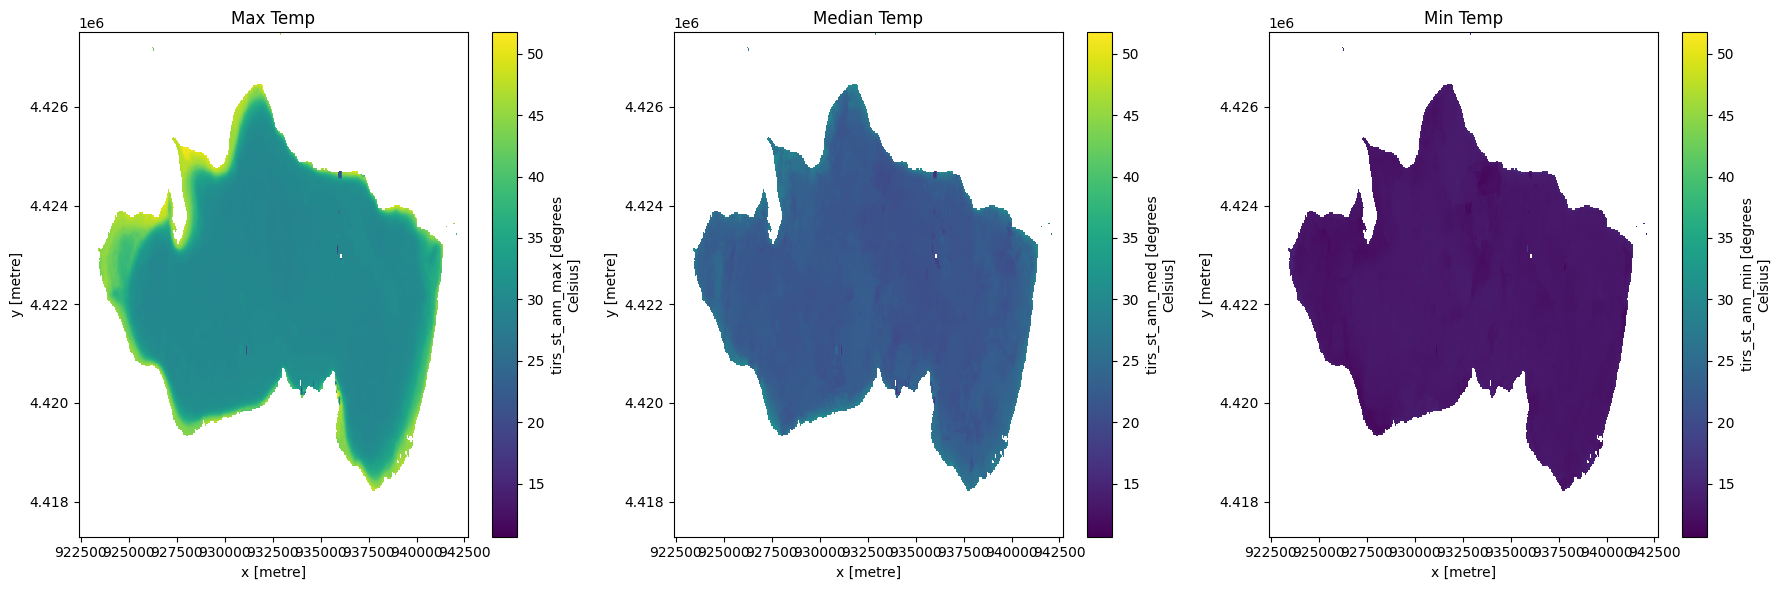

In [15]:
# The TIRS variables
tirs_vars = ["tirs_st_ann_max", "tirs_st_ann_med", "tirs_st_ann_min"]
titles = ["Max Temp", "Median Temp", "Min Temp"]

# Compute a common vmin/vmax for consistent colors
vmin = min(ds[var].sel(time="2024").min().item() for var in tirs_vars)
vmax = max(ds[var].sel(time="2024").max().item() for var in tirs_vars)

fig, axes = plt.subplots(1, 3, figsize=(18,6))

for ax, var, title in zip(axes, tirs_vars, titles):
    im = ds[var].sel(time="2024").plot(ax=ax, vmin=vmin, vmax=vmax, robust=True)
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Yearly change monitoring

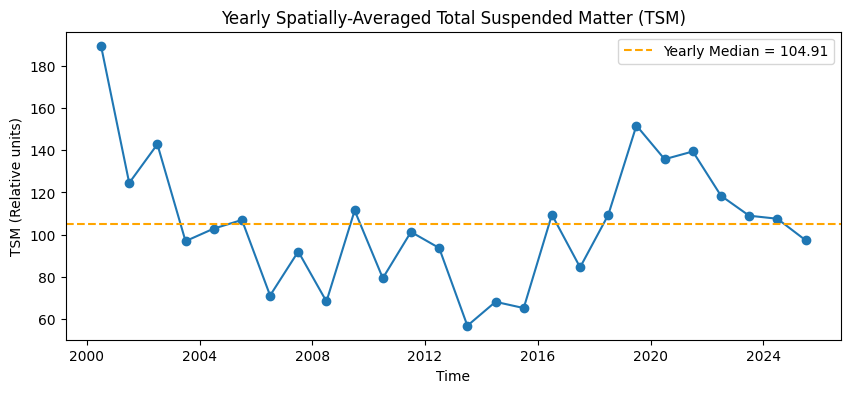

In [16]:
# Spatially averaged time series
ts = ds.mean(dim=["x", "y"])

# Compute median over all years
median_value = ts["tsm"].median().item()

# Plot the time series with markers
ax = ts["tsm"].plot.line(marker='o', figsize=(10,4))

# Add horizontal line for the median
plt.axhline(median_value, color='orange', linestyle='--', label=f"Yearly Median = {median_value:.2f}")

# Labels and legend
plt.title("Yearly Spatially-Averaged Total Suspended Matter (TSM)")
plt.xlabel("Time")
plt.ylabel("TSM (Relative units)")
plt.legend()
plt.show()

## Animation over time

Exporting animation to animation.mp4


  0%|          | 0/26 (0.0 seconds remaining at ? frames/s)

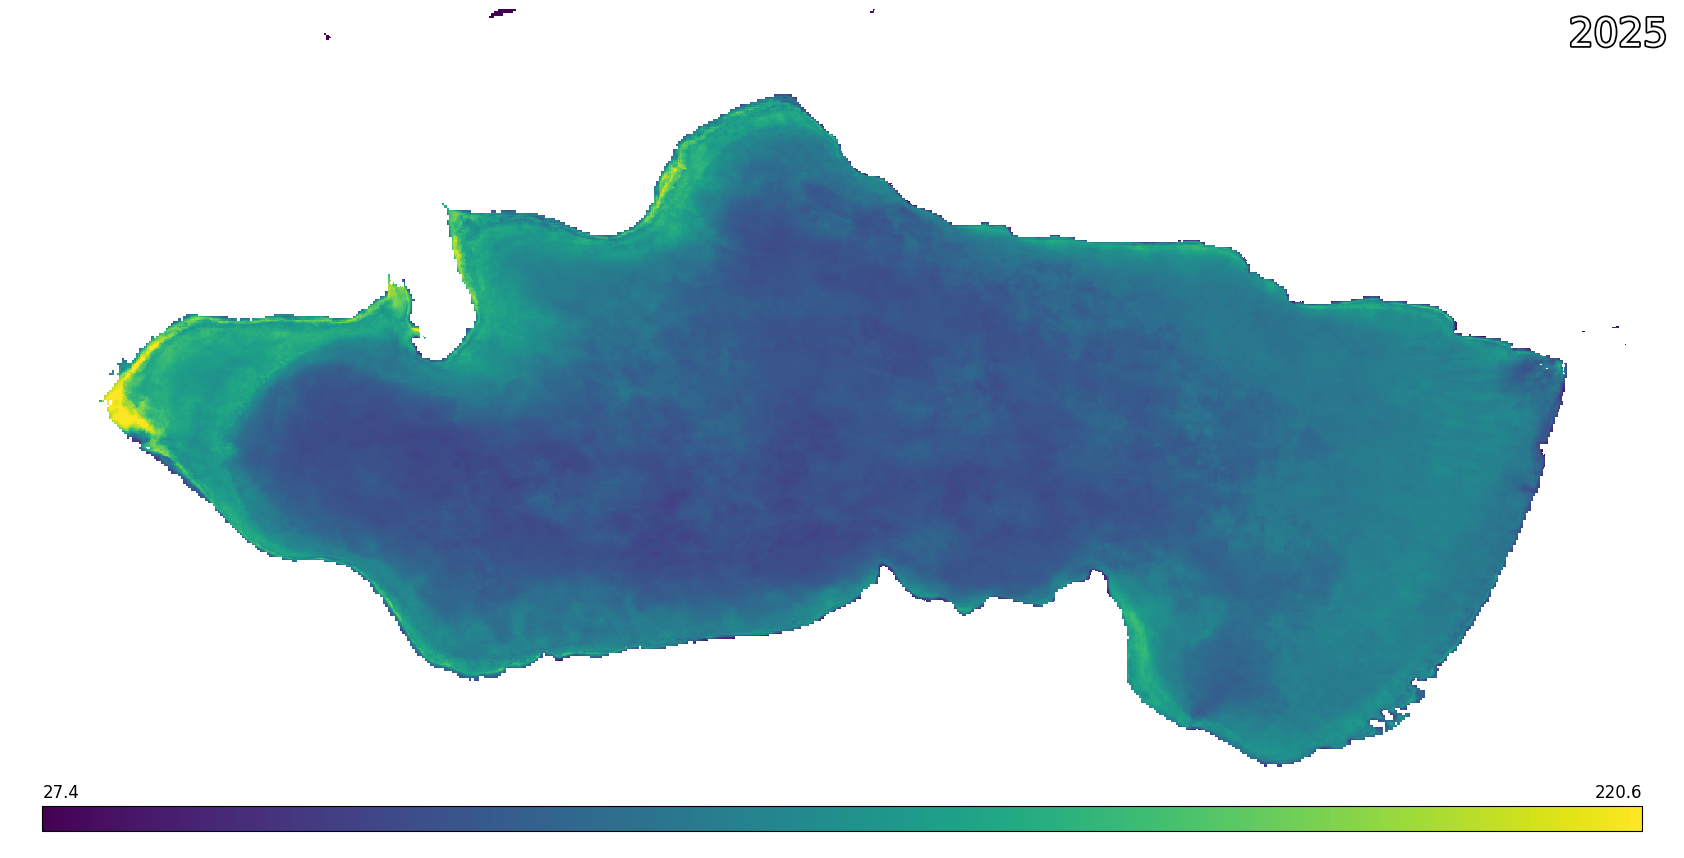

In [20]:
xr_animation(
    ds,
    bands="tsm",
    interval=500,
    show_date="%Y",
    annotation_kwargs={"fontsize": 28},
    imshow_kwargs={"cmap": "viridis"},
    colorbar_kwargs={"labelcolor": "black"},
    width_pixels = 1200
)

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Africa data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Slack channel](http://slack.opendatacube.org/) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [Github](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks).

**Compatible datacube version:** 

In [18]:
print(datacube.__version__)

1.9.13


**Last Tested:**

In [19]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2026-03-16'